# STEP 1: Import Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# STEP 2: Load Dataset

In [4]:
vocab_size = 10000
max_length = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


# STEP 3: Padding

In [5]:
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print("Shape after padding:", X_train.shape)

Shape after padding: (25000, 200)


# STEP 4: Build LSTM Model

In [12]:
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(Embedding(vocab_size, 128, input_length=max_length))

model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(32))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# STEP 5: Train Model

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 130s 398ms/step - accuracy: 0.7921 - loss: 0.4470 - val_accuracy: 0.8642 - val_loss: 0.3295
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 314ms/step - accuracy: 0.8932 - loss: 0.2732 - val_accuracy: 0.8542 - val_loss: 0.3357
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 262ms/step - accuracy: 0.9295 - loss: 0.1942 - val_accuracy: 0.8572 - val_loss: 0.3484
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 263ms/step - accuracy: 0.9510 - loss: 0.1390 - val_accuracy: 0.8610 - val_loss: 0.3624
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.9636 - loss: 0.1066 - val_accuracy: 0.8594 - val_loss: 0.5660


# STEP 6: Evaluate Model

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.8418 - loss: 0.6307
Test Accuracy: 0.8417999744415283


# STEP 7: Plot Accuracy & Loss

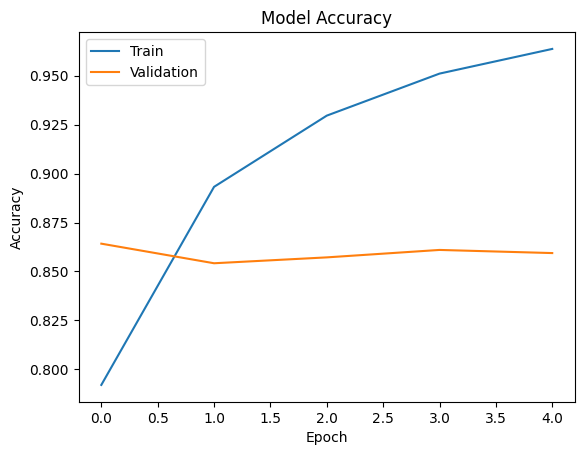

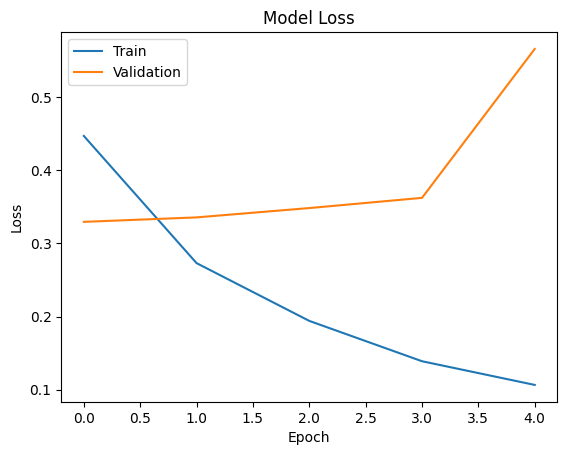

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# STEP 8: Save Model

In [17]:
model.save("sentiment_lstm_model.h5")

# STEP 9: Show 5 Sample Predictions

In [18]:
for i in range(5):
    prediction = model.predict(X_test[i].reshape(1, max_length))
    
    print("Review", i+1)
    print("Predicted:", "Positive" if prediction > 0.5 else "Negative")
    print("Actual:", "Positive" if y_test[i] == 1 else "Negative")
    print("---------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
Review 1
Predicted: Positive
Actual: Negative
---------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Review 2
Predicted: Positive
Actual: Positive
---------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Review 3
Predicted: Negative
Actual: Positive
---------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Review 4
Predicted: Positive
Actual: Negative
---------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Review 5
Predicted: Positive
Actual: Positive
---------------
